# Water Pouring Problem (Jug Problem)

## Problem Description



**Goal:** Minimize steps needed to measure 1 gallon of water with available mugs.

**State:** Describes available mugs and water level in them at the moment.

**Initial State:** Facet and 12, 8, and 3 gallon mugs. All mugs are empty.

**Actions:**
- `fill_mug()` - fill mug from faucet or other mug
- `empty_mug()` - empty the mug onto the ground

**Transition Map:**
- `fill_mug(src, tgt)` fills mug from faucet or other mug
- `empty_mug(mug)` empties the mug onto the ground

**Goal Test:** Measures if a single mug contains the goal amount of water (1 gallon).

**Step Cost:** 
- Fill cost: 1
- Empty cost: 2 (to penalize water wasting)

**Path Cost:** Sum of step costs

## Implementation

### Imports

In [2]:
import sys
sys.path.append('../..')

from search4e import *
import matplotlib.pyplot as plt
import numpy as np

### JugProblem Class

This class extends `Problem` from search4e.py and implements water pouring logic with custom action costs:
- **State**: Tuple of water levels in each jug
- **Actions**: Fill (from faucet), Dump (empty jug), Pour (between jugs)
- **Custom Costs**: Fill = 1, Empty (Dump) = 2 (penalizes water wasting), Pour = 1

In [3]:
class JugProblem(Problem):
    """Water pouring problem about achieving a target water level.
    
    State is a tuple of water levels. In initialization, provide:
    - initial: tuple of starting water levels (e.g., (0, 0, 0))
    - goal: target water level to achieve in any jug
    - sizes: tuple of jug capacities (e.g., (12, 8, 3))
    
    Custom costs: Fill = 1, Dump = 2 (penalizes wasting), Pour = 1
    """
    
    def actions(self, state):
        """The actions executable in this state."""
        jugs = range(len(state))
        return ([('Fill', i)    for i in jugs if state[i] < self.sizes[i]] +
                [('Dump', i)    for i in jugs if state[i]] +
                [('Pour', i, j) for i in jugs if state[i] for j in jugs if i != j])

    def result(self, state, action):
        """The state that results from executing this action in this state."""
        result = list(state)
        act, i, *_ = action
        if act == 'Fill':   # Fill i to capacity
            result[i] = self.sizes[i]
        elif act == 'Dump': # Empty i
            result[i] = 0
        elif act == 'Pour': # Pour from i into j
            j = action[2]
            amount = min(state[i], self.sizes[j] - state[j])
            result[i] -= amount
            result[j] += amount
        return tuple(result)

    def is_goal(self, state):
        """True if the goal level is in any one of the jugs."""
        return self.goal in state
    
    def action_cost(self, s, action, s1):
        """Return the cost of taking an action.
        Fill = 1, Dump = 2 (penalizes wasting water), Pour = 1"""
        act = action[0]
        if act == 'Fill':
            return 1
        elif act == 'Dump':
            return 2  # Higher cost to penalize water wasting
        elif act == 'Pour':
            return 1
        return 1  # Default cost

### Problem Instance

Create the jug problem with:
- Three jugs of sizes 12, 8, and 3 gallons
- Goal: measure exactly 1 gallon
- Initial state: all jugs empty (0, 0, 0)

In [4]:
jugs_problem = JugProblem(initial=(0, 0, 0), goal=1, sizes=(12, 8, 3))
print(f"Initial state: {jugs_problem.initial}")
print(f"Goal: {jugs_problem.goal} gallon")
print(f"Jug sizes: {jugs_problem.sizes} gallons")

Initial state: (0, 0, 0)
Goal: 1 gallon
Jug sizes: (12, 8, 3) gallons


### Test Actions

Explore available actions from the initial state and test state transitions.

In [5]:
# Available actions from initial state
initial_actions = jugs_problem.actions(jugs_problem.initial)
print(f"Available actions from initial state {jugs_problem.initial}:")
for action in initial_actions:
    print(f"  {action}")

# Test a few actions
print("\nTesting state transitions:")
state1 = jugs_problem.result(jugs_problem.initial, ('Fill', 0))
print(f"After filling jug 0: {state1}")

state2 = jugs_problem.result(state1, ('Pour', 0, 1))
print(f"After pouring from jug 0 to jug 1: {state2}")

state3 = jugs_problem.result(state2, ('Pour', 0, 2))
print(f"After pouring from jug 0 to jug 2: {state3}")

# Check action costs
print("\nAction costs:")
print(f"  Fill jug 0: {jugs_problem.action_cost(jugs_problem.initial, ('Fill', 0), state1)}")
print(f"  Dump jug 0: {jugs_problem.action_cost(state1, ('Dump', 0), jugs_problem.initial)}")
print(f"  Pour from jug 0 to 1: {jugs_problem.action_cost(state1, ('Pour', 0, 1), state2)}")

Available actions from initial state (0, 0, 0):
  ('Fill', 0)
  ('Fill', 1)
  ('Fill', 2)

Testing state transitions:
After filling jug 0: (12, 0, 0)
After pouring from jug 0 to jug 1: (4, 8, 0)
After pouring from jug 0 to jug 2: (1, 8, 3)

Action costs:
  Fill jug 0: 1
  Dump jug 0: 2
  Pour from jug 0 to 1: 1


### Solve with A* Search

Use A* search algorithm to find the optimal solution.

In [6]:
# Solve using A* search
solution = astar_search(jugs_problem)

if solution:
    actions = path_actions(solution)
    states = path_states(solution)
    
    print("Solution found!")
    print(f"\nNumber of steps: {len(actions)}")
    print(f"Total cost: {solution.path_cost}")
    
    print("\nSolution path:")
    for i, (state, action) in enumerate(zip(states, actions + [None])):
        print(f"Step {i}: State = {state}", end="")
        if action:
            print(f" → Action: {action}")
        else:
            print(" (GOAL)")
else:
    print("No solution found!")

Solution found!

Number of steps: 3
Total cost: 3

Solution path:
Step 0: State = (0, 0, 0) → Action: ('Fill', 0)
Step 1: State = (12, 0, 0) → Action: ('Pour', 0, 1)
Step 2: State = (4, 8, 0) → Action: ('Pour', 0, 2)
Step 3: State = (1, 8, 3) (GOAL)


### Algorithm Comparison

Compare different search algorithms on the jug problem.

In [9]:
import time

def compare_algorithms(problem):
    """Compare different search algorithms on the given problem."""
    algorithms = {
        'Breadth-First': breadth_first_search,
        'Depth-First BFS': depth_first_bfs,
        'Uniform-Cost': uniform_cost_search,
        'A* Search': astar_search,
    }
    
    results = []
    
    print("Algorithm Comparison:\n" + "="*70)
    
    for name, algorithm in algorithms.items():
        try:
            start_time = time.time()
            solution = algorithm(problem)
            end_time = time.time()
            
            if solution:
                actions = path_actions(solution)
                cost = solution.path_cost
                time_taken = (end_time - start_time) * 1000  # Convert to milliseconds
                
                results.append({
                    'Algorithm': name,
                    'Steps': len(actions),
                    'Cost': cost,
                    'Time (ms)': f'{time_taken:.2f}'
                })
                
                print(f"{name:20} | Steps: {len(actions):2} | Cost: {cost:4.1f} | Time: {time_taken:6.2f} ms")
            else:
                print(f"{name:20} | No solution found")
        except Exception as e:
            print(f"{name:20} | Error: {str(e)}")
    
    return results

results = compare_algorithms(jugs_problem)

Algorithm Comparison:
Breadth-First        | Steps:  3 | Cost:  3.0 | Time:   0.18 ms
Depth-First BFS      | Steps: 21 | Cost: 24.0 | Time:   0.74 ms
Uniform-Cost         | Steps:  3 | Cost:  3.0 | Time:   0.56 ms
A* Search            | Steps:  3 | Cost:  3.0 | Time:   0.53 ms


### Performance Report

Detailed performance analysis of the solution.

In [10]:
def performance_report(problem, solution):
    """Generate a detailed performance report."""
    if not solution:
        print("No solution to report on")
        return
    
    actions = path_actions(solution)
    states = path_states(solution)
    
    print("=" * 70)
    print("PERFORMANCE REPORT: Water Pouring Problem")
    print("=" * 70)
    
    print(f"\nProblem Configuration:")
    print(f"  Jug Sizes: {problem.sizes} gallons")
    print(f"  Goal: {problem.goal} gallon")
    print(f"  Initial State: {problem.initial}")
    
    print(f"\nSolution Metrics:")
    print(f"  Total Steps: {len(actions)}")
    print(f"  Total Path Cost: {solution.path_cost}")
    print(f"  Final State: {states[-1]}")
    
    # Count action types
    fill_count = sum(1 for a in actions if a[0] == 'Fill')
    dump_count = sum(1 for a in actions if a[0] == 'Dump')
    pour_count = sum(1 for a in actions if a[0] == 'Pour')
    
    print(f"\nAction Breakdown:")
    print(f"  Fill actions: {fill_count} (cost: {fill_count * 1})")
    print(f"  Dump actions: {dump_count} (cost: {dump_count * 2})")
    print(f"  Pour actions: {pour_count} (cost: {pour_count * 1})")
    print(f"  Total cost: {fill_count * 1 + dump_count * 2 + pour_count * 1}")
    
    print(f"\nEfficiency:")
    avg_cost_per_step = solution.path_cost / len(actions) if actions else 0
    print(f"  Average cost per step: {avg_cost_per_step:.2f}")
    print(f"  Water wasting penalty applied: {dump_count} times")
    
    print("\n" + "=" * 70)

performance_report(jugs_problem, solution)

PERFORMANCE REPORT: Water Pouring Problem

Problem Configuration:
  Jug Sizes: (12, 8, 3) gallons
  Goal: 1 gallon
  Initial State: (0, 0, 0)

Solution Metrics:
  Total Steps: 3
  Total Path Cost: 3
  Final State: (1, 8, 3)

Action Breakdown:
  Fill actions: 1 (cost: 1)
  Dump actions: 0 (cost: 0)
  Pour actions: 2 (cost: 2)
  Total cost: 3

Efficiency:
  Average cost per step: 1.00
  Water wasting penalty applied: 0 times



### Visualization

Visualize the jugs as vertical bars showing water levels at each step.

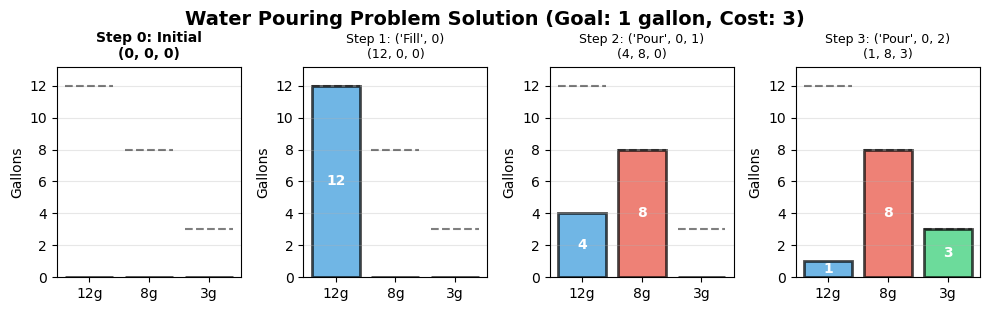

In [11]:
def visualize_jug_solution(problem, solution):
    """Visualize the jug problem solution as vertical bar charts."""
    if not solution:
        print("No solution to visualize")
        return
    
    states = path_states(solution)
    actions = path_actions(solution)
    
    num_steps = len(states)
    num_jugs = len(problem.sizes)
    
    # Create subplot grid
    cols = min(5, num_steps)
    rows = (num_steps + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 3))
    if num_steps == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Color map for jugs
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    
    for step, (state, ax) in enumerate(zip(states, axes)):
        # Plot each jug
        x_pos = np.arange(num_jugs)
        bars = ax.bar(x_pos, state, color=[colors[i % len(colors)] for i in range(num_jugs)],
                      edgecolor='black', linewidth=2, alpha=0.7)
        
        # Add capacity lines
        for i, size in enumerate(problem.sizes):
            ax.plot([i - 0.4, i + 0.4], [size, size], 'k--', linewidth=1.5, alpha=0.5)
        
        # Labels and formatting
        ax.set_ylim(0, max(problem.sizes) * 1.1)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f"{size}g" for size in problem.sizes])
        ax.set_ylabel('Gallons')
        
        # Title with action
        if step == 0:
            ax.set_title(f'Step {step}: Initial\n{state}', fontsize=10, fontweight='bold')
        else:
            action_str = str(actions[step-1])
            ax.set_title(f'Step {step}: {action_str}\n{state}', fontsize=9)
        
        # Add value labels on bars
        for i, (bar, val) in enumerate(zip(bars, state)):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, val/2, f'{val}',
                       ha='center', va='center', fontweight='bold', color='white')
        
        ax.grid(axis='y', alpha=0.3)
    
    # Hide unused subplots
    for i in range(num_steps, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f'Water Pouring Problem Solution (Goal: {problem.goal} gallon, Cost: {solution.path_cost})',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.show()

# Visualize the solution
visualize_jug_solution(jugs_problem, solution)